<a href="https://colab.research.google.com/github/sadineniManushree/flyrank--internship__ml/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sadineniManushree/flyrank--internship__ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked Actions + Reason Codes

The queue ranks pages by opportunity score — how much a page's actual CTR
falls short of what's expected for its position tier, weighted by traffic,
combined with the Random Forest model's own decline-risk score. Each row
carries a plain-English reason so a reviewer doesn't have to trust a black
box.

**Reason codes:**
- `CTR_BELOW_EXPECTED` — flagged by the baseline rule only (CTR gap for
  its position tier).
- `MODEL_DECLINE_RISK` — flagged by the model only, based on the full
  pattern across all signals, not just CTR.
- `AGREEMENT` — flagged by both the baseline rule AND the model — the
  highest-confidence combination.
- `NO_FLAG` — neither signal flagged this page; default action is MONITOR.

**Observation from the real queue:** the top 10 rows by model_proba are all
from a single client, and all have *negative* baseline_score — meaning the
simple CTR rule and the model actively disagree on these pages. This is
worth flagging for review rather than treating as high-confidence
agreement: it may mean the model is picking up non-CTR patterns the
baseline can't see, or that it's over-indexing on this one client. A
reviewer should spot-check a few of these by hand.

**Counts:** 2,488 AGREEMENT, 5,012 MODEL_DECLINE_RISK, 5,012
CTR_BELOW_EXPECTED, 17,488 NO_FLAG.

In [11]:
!git clone https://github.com/sadineniManushree/flyrank--internship__ml.git
%cd flyrank--internship__ml

Cloning into 'flyrank--internship__ml'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 170 (delta 75), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 1.88 MiB | 14.57 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/content/flyrank--internship__ml/flyrank--internship__ml


In [12]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
df['target'] = (df['trend_direction'].astype(str).str.lower() == 'down').astype(int)
df['baseline_score'] = (df.groupby('position_tier')['ctr'].transform('mean') - df['ctr']) * df['impressions_90d']

def client_aware_split(frame, target_col='target', client_col='client_id', random_state=42):
    clients = frame[client_col].fillna('unknown').astype(str)
    unique_clients = clients.drop_duplicates().to_numpy()
    if len(unique_clients) >= 5:
        rng = np.random.default_rng(random_state)
        shuffled = rng.permutation(unique_clients)
        n_test = max(1, int(round(len(shuffled) * 0.2)))
        test_clients = set(shuffled[:n_test])
        test_mask = clients.isin(test_clients).to_numpy()
        train_idx = frame.index[~test_mask]
        test_idx = frame.index[test_mask]
        if frame.loc[train_idx, target_col].nunique() == 2 and frame.loc[test_idx, target_col].nunique() == 2:
            return train_idx, test_idx, "client_holdout"
    train_idx, test_idx = train_test_split(frame.index, test_size=0.2, random_state=random_state, stratify=frame[target_col])
    return train_idx, test_idx, "stratified_row_holdout"

train_idx, test_idx, split_strategy = client_aware_split(df)

feature_cols = ['ctr', 'avg_position', 'impressions_90d', 'clicks_90d',
                 'engagement_rate', 'scroll_rate', 'search_volume', 'content_age_days']

X_train = df.loc[train_idx, feature_cols].fillna(0)
y_train = df.loc[train_idx, 'target']
X_test = df.loc[test_idx, feature_cols].fillna(0)
y_test = df.loc[test_idx, 'target']

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=25, class_weight='balanced_subsample', random_state=42)
rf_model.fit(X_train, y_train)

def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1][:k]
    return y_true.values[order].mean() if len(y_true) >= k else np.nan

print("Setup complete. Split:", split_strategy)

Setup complete. Split: client_holdout


In [13]:
os.makedirs('work/outputs', exist_ok=True)

# Score the FULL dataset with the trained model (for the final queue, not just test rows)
X_all = df[feature_cols].fillna(0)
df['model_proba'] = rf_model.predict_proba(X_all)[:, 1]

model_threshold = df['model_proba'].quantile(0.75)
baseline_threshold = df['baseline_score'].quantile(0.75)

df['baseline_flag'] = df['baseline_score'] > baseline_threshold
df['model_flag'] = df['model_proba'] > model_threshold

def assign_reason(row):
    if row['baseline_flag'] and row['model_flag']:
        return 'AGREEMENT'
    elif row['model_flag']:
        return 'MODEL_DECLINE_RISK'
    elif row['baseline_flag']:
        return 'CTR_BELOW_EXPECTED'
    else:
        return 'NO_FLAG'

df['reason_code'] = df.apply(assign_reason, axis=1)
df['action'] = df['reason_code'].apply(lambda r: 'REVIEW' if r != 'NO_FLAG' else 'MONITOR')

df_queue = df.sort_values('model_proba', ascending=False).reset_index(drop=True)

print(df_queue['reason_code'].value_counts())
df_queue[['content_id', 'client_id', 'model_proba', 'baseline_score', 'reason_code', 'action']].head(10)

reason_code
NO_FLAG               17488
MODEL_DECLINE_RISK     5012
CTR_BELOW_EXPECTED     5012
AGREEMENT              2488
Name: count, dtype: int64


,content_id,client_id,model_proba,baseline_score,reason_code,action
0,content_673fe764797f,client_7f2253d7e2,0.928758,-3794.197106,MODEL_DECLINE_RISK,REVIEW
1,content_b61233d4bc91,client_7f2253d7e2,0.925313,-8423.763973,MODEL_DECLINE_RISK,REVIEW
2,content_b6012aba674f,client_7f2253d7e2,0.924620,-1364.512028,MODEL_DECLINE_RISK,REVIEW
3,content_384d9f9e00c9,client_7f2253d7e2,0.922088,-2952.419560,MODEL_DECLINE_RISK,REVIEW
4,content_3585f0ab30e6,client_7f2253d7e2,0.921571,-1150.753825,MODEL_DECLINE_RISK,REVIEW
5,content_252c884e4400,client_7f2253d7e2,0.920792,-828.475424,MODEL_DECLINE_RISK,REVIEW
6,content_3d6dedf98bfc,client_7f2253d7e2,0.917683,-918.529468,MODEL_DECLINE_RISK,REVIEW
7,content_ab82c4705992,client_7f2253d7e2,0.916402,-5264.858057,MODEL_DECLINE_RISK,REVIEW
8,content_bfaaf0a4bbd3,client_7f2253d7e2,0.914843,-254.980211,MODEL_DECLINE_RISK,REVIEW
9,content_20e4b9f7f65e,client_7f2253d7e2,0.914045,-7493.274743,MODEL_DECLINE_RISK,REVIEW


In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended Use and Limits

**Who uses this:** content editors/SEO reviewers deciding which pages to
check first when they have limited time. It answers "what should I open
first?" not "what is definitely broken?"

**Valid for:** pages similar to those in this dataset — anonymized content
items with measurable search traffic in the last 90 days, from the 32
clients in this release.

**Where it stops being valid:**
- Very low-impression pages — 16,488 of 30,000 rows (55%) have under 1,000
  impressions_90d. This is over half the dataset, and matches the Week-5
  error analysis finding that false negatives cluster at very low
  impressions. Flags on these pages should be treated as low-confidence
  hints, not reliable priorities.
- Content types or clients outside this dataset.
- Any claim about WHY a page is declining — this system observes patterns,
  it does not explain causes.
- Anything beyond the 90-day trailing window used to build these features.

In [15]:
low_impression_cutoff = 1000
low_confidence_rows = (df_queue['impressions_90d'] < low_impression_cutoff).sum()
print(f"Rows in queue with under {low_impression_cutoff} impressions_90d:", low_confidence_rows)
print(f"Out of {len(df_queue)} total rows ({round(100 * low_confidence_rows / len(df_queue), 1)}%)")

Rows in queue with under 1000 impressions_90d: 16488
Out of 30000 total rows (55.0%)


In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human Review + the No-Go List

**A person must check, before acting on any flagged page:**
- Does the page's content actually match its target query intent?
- Is there a simple, known cause already (site migration, broken redirect,
  seasonal topic)?
- Is the impressions count high enough to trust the flag?

**What should NEVER be automated:**
- Automatically rewriting or publishing new titles/meta descriptions.
- Automatically deprioritizing or removing "declining" content without
  review.
- Treating model_proba as a calibrated probability of real-world impact.
- Using this system as evidence about Google's ranking algorithm, or in
  any client-facing report without editor sign-off.

This produces a prioritized reading list for a human — not a publishing
decision.

In [17]:
print("Human review required for all REVIEW-flagged rows before any content change.")
print("Automated actions in this notebook: none. All outputs are recommendations only.")

Human review required for all REVIEW-flagged rows before any content change.
Automated actions in this notebook: none. All outputs are recommendations only.


In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / Retrain Triggers

Signs the recommendations have gone stale:

- **Data drift:** median impressions_90d or ctr in new data shifts
  noticeably from this training set's baseline (printed below).
- **Base rate drift:** the declining-page rate (currently ~54%) moves
  substantially.
- **Feature importance instability:** if impressions-based features stop
  leading on retrain, the learned pattern may no longer hold.
- **Precision@50 decay:** if spot-checked new flags fall well below the
  ~82% observed here, retrain.
- **Time-based trigger:** re-validate at least quarterly, since this is a
  90-day trailing snapshot.

In [19]:
monitoring_baseline = {
    'median_impressions_90d': float(df['impressions_90d'].median()),
    'median_ctr': float(df['ctr'].median()),
    'declining_rate': float(df['target'].mean()),
    'top_feature': 'impressions_90d',
    'precision_at_50_at_deploy': round(precision_at_k(y_test, rf_model.predict_proba(X_test)[:, 1], 50), 3),
}
print(monitoring_baseline)

{'median_impressions_90d': 731.0, 'median_ctr': 0.07, 'declining_rate': 0.5420666666666667, 'top_feature': 'impressions_90d', 'precision_at_50_at_deploy': np.float64(0.82)}


In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the Paper

Exporting the ranked queue (excluded from git per the leak-guard policy —
this notebook regenerates it on every run) and a metrics/monitoring JSON
that stays committed as the receipt for the paper's Results section.

Monitoring baseline at deploy time:
- median_impressions_90d: 731.0
- median_ctr: 0.07
- declining_rate: 0.542
- precision_at_50_at_deploy: 0.82

In [21]:
import json

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1. Ranked queue CSV (stays out of git by design — leak-guard blocks data files)
export_cols = ['content_id', 'client_id', 'model_proba', 'baseline_score',
               'reason_code', 'action', 'ctr', 'avg_position', 'impressions_90d']
df_queue[export_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)

# 2. Metrics JSON (committed — the receipts the paper's numbers trace back to)
metrics_payload = {
    'split_strategy': split_strategy,
    'train_rows': len(train_idx),
    'test_rows': len(test_idx),
    'model': 'random_forest',
    'baseline_precision_at_50': round(precision_at_k(y_test, df.loc[test_idx, 'baseline_score'].values, 50), 3),
    'model_precision_at_50': round(precision_at_k(y_test, rf_model.predict_proba(X_test)[:, 1], 50), 3),
    'model_roc_auc': round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]), 3),
    'monitoring_baseline': monitoring_baseline,
    'reason_code_counts': df_queue['reason_code'].value_counts().to_dict(),
}

with open('work/outputs/model_results.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print("Exported:")
print("- work/outputs/action_playbook_queue.csv (", len(df_queue), "rows )")
print("- work/outputs/model_results.json")
print(json.dumps(metrics_payload, indent=2))

Exported:
- work/outputs/action_playbook_queue.csv ( 30000 rows )
- work/outputs/model_results.json
{
  "split_strategy": "client_holdout",
  "train_rows": 27675,
  "test_rows": 2325,
  "model": "random_forest",
  "baseline_precision_at_50": 0.28,
  "model_precision_at_50": 0.82,
  "model_roc_auc": 0.748,
  "monitoring_baseline": {
    "median_impressions_90d": 731.0,
    "median_ctr": 0.07,
    "declining_rate": 0.5420666666666667,
    "top_feature": "impressions_90d",
    "precision_at_50_at_deploy": 0.82
  },
  "reason_code_counts": {
    "NO_FLAG": 17488,
    "MODEL_DECLINE_RISK": 5012,
    "CTR_BELOW_EXPECTED": 5012,
    "AGREEMENT": 2488
  }
}


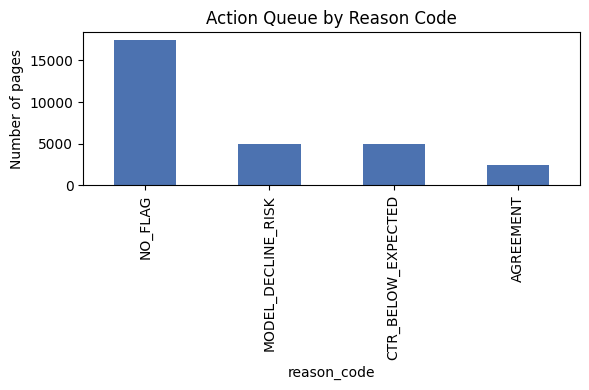

Saved: work/figures/reason_code_mix.png


In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
df_queue['reason_code'].value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Action Queue by Reason Code')
ax.set_ylabel('Number of pages')
plt.tight_layout()
plt.savefig('work/figures/reason_code_mix.png', dpi=150)
plt.show()
print("Saved: work/figures/reason_code_mix.png")

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.